# Анализ сайта «СберАвтоподписка» — Предсказание конверсии

**Цель проекта:** Построить модель, предсказывающую вероятность того, что пользователь совершит целевое действие на сайте (оставит заявку, закажет звонок и пр.)

**Бизнес-задача:** Помочь компании оценивать эффективность каналов привлечения, адаптировать рекламные кампании и улучшать UX сайта.

## 1. Загрузка и очистка данных

In [1]:
# Импорт библиотек
import pandas as pd          # Работа с таблицами
import numpy as np            # Числовые операции
import matplotlib.pyplot as plt  # Построение графиков
import seaborn as sns         # Расширенная визуализация
import warnings
from datetime import datetime

# Отключаем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Настройка отображения таблиц pandas
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


In [2]:
# Загрузка данных из pickle-файлов
DATA_PATH = '../Проектный практикум (хакатон)/'

sessions = pd.read_pickle(DATA_PATH + 'ga_sessions.pkl')
hits = pd.read_pickle(DATA_PATH + 'ga_hits.pkl')

print(f"GA Sessions: {sessions.shape[0]:,} строк, {sessions.shape[1]} столбцов")
print(f"GA Hits: {hits.shape[0]:,} строк, {hits.shape[1]} столбцов")

GA Sessions: 1,860,042 строк, 18 столбцов
GA Hits: 15,726,470 строк, 11 столбцов


In [3]:
# Первичный осмотр данных — сессии
print("=== GA Sessions — первые 5 строк ===")
sessions.head()

=== GA Sessions — первые 5 строк ===


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [4]:
# Типы данных и пропуски в сессиях
# Проверяем типы данных для корректной обработки и наличие пропусков
print("=== Типы данных (sessions) ===")
print(sessions.dtypes)
print(f"\n=== Пропуски (sessions) ===")
print(sessions.isnull().sum())
# Процент пропусков помогает решить: удалять строки или заполнять значениями
print(f"\nДоля пропусков (%):")
print((sessions.isnull().sum() / len(sessions) * 100).round(2))

=== Типы данных (sessions) ===
session_id                  object
client_id                   object
visit_date                  object
visit_time                  object
visit_number                 int64
utm_source                  object
utm_medium                  object
utm_campaign                object
utm_adcontent               object
utm_keyword                 object
device_category             object
device_os                   object
device_brand                object
device_model                object
device_screen_resolution    object
device_browser              object
geo_country                 object
geo_city                    object
dtype: object

=== Пропуски (sessions) ===


session_id                        0
client_id                         0
visit_date                        0
visit_time                        0
visit_number                      0
utm_source                       97
utm_medium                        0
utm_campaign                 219603
utm_adcontent                335615
utm_keyword                 1082061
device_category                   0
device_os                   1070138
device_brand                 118678
device_model                1843704
device_screen_resolution          0
device_browser                    0
geo_country                       0
geo_city                          0
dtype: int64

Доля пропусков (%):


session_id                   0.00
client_id                    0.00
visit_date                   0.00
visit_time                   0.00
visit_number                 0.00
utm_source                   0.01
utm_medium                   0.00
utm_campaign                11.81
utm_adcontent               18.04
utm_keyword                 58.17
device_category              0.00
device_os                   57.53
device_brand                 6.38
device_model                99.12
device_screen_resolution     0.00
device_browser               0.00
geo_country                  0.00
geo_city                     0.00
dtype: float64


In [5]:
# Первичный осмотр данных — хиты
print("=== GA Hits — первые 5 строк ===")
hits.head()

=== GA Hits — первые 5 строк ===


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,None
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,None
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,None
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,None
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,None


In [6]:
# Типы данных и пропуски в хитах
# Аналогичный анализ для таблицы событий
print("=== Типы данных (hits) ===")
print(hits.dtypes)
print(f"\n=== Пропуски (hits) ===")
print(hits.isnull().sum())
# Высокий процент пропусков в event-полях ожидаем: не все хиты — события
print(f"\nДоля пропусков (%):")
print((hits.isnull().sum() / len(hits) * 100).round(2))

=== Типы данных (hits) ===
session_id         object
hit_date           object
hit_time          float64
hit_number          int64
hit_type           object
hit_referer        object
hit_page_path      object
event_category     object
event_action       object
event_label        object
event_value        object
dtype: object

=== Пропуски (hits) ===


session_id               0
hit_date                 0
hit_time           9160322
hit_number               0
hit_type                 0
hit_referer        6274804
hit_page_path            0
event_category           0
event_action             0
event_label        3760184
event_value       15726470
dtype: int64

Доля пропусков (%):


session_id          0.00
hit_date            0.00
hit_time           58.25
hit_number          0.00
hit_type            0.00
hit_referer        39.90
hit_page_path       0.00
event_category      0.00
event_action        0.00
event_label        23.91
event_value       100.00
dtype: float64


In [7]:
# Очистка данных — сессии

# Удаление дубликатов по session_id
before = len(sessions)
sessions = sessions.drop_duplicates(subset='session_id')
print(f"Удалено дубликатов в sessions: {before - len(sessions)}")

# Приведение visit_date к datetime
sessions['visit_date'] = pd.to_datetime(sessions['visit_date'])

# Извлечение часа визита из visit_time
# visit_time — строка вида "HH:MM:SS"
sessions['visit_hour'] = pd.to_datetime(sessions['visit_time'], format='%H:%M:%S', errors='coerce').dt.hour

# Извлечение дня недели
sessions['day_of_week'] = sessions['visit_date'].dt.dayofweek  # 0=Пн, 6=Вс
sessions['is_weekend'] = sessions['day_of_week'].isin([5, 6]).astype(int)

# Заполнение пропусков в категориальных признаках
cat_cols = ['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
            'utm_keyword', 'device_category', 'device_os', 'device_brand',
            'device_model', 'device_screen_resolution', 'device_browser',
            'geo_country', 'geo_city']

for col in cat_cols:
    if col in sessions.columns:
        sessions[col] = sessions[col].fillna('unknown')
        # Заменим также пустые строки и (not set) на unknown
        sessions[col] = sessions[col].replace({'': 'unknown', '(not set)': 'unknown', '(none)': 'unknown_none'})

print(f"Пропуски после очистки:\n{sessions.isnull().sum().sum()} пропусков")
print(f"\nИтого строк: {len(sessions):,}")

Удалено дубликатов в sessions: 0


Пропуски после очистки:
0 пропусков

Итого строк: 1,860,042


In [8]:
# Определяем целевые действия (конверсионные события)
# Это ключевые события, указывающие на совершение целевого действия пользователем

TARGET_ACTIONS = [
    'sub_submit_success',              # Успешная отправка заявки на подписку
    'sub_car_claim_submit_click',      # Клик на отправку заявки на автомобиль
    'sub_callback_submit_click',       # Клик на заказ обратного звонка
    'sub_car_request_submit_click',    # Клик на отправку запроса на авто
    'sub_custom_question_submit_click',# Отправка пользовательского вопроса
    'greenday_sub_callback_submit_click', # Заказ звонка (акция Green Day)
    'greenday_sub_submit_success',     # Успешная заявка (акция Green Day)
]

# Находим session_id, в которых произошло целевое действие
target_sessions = hits[hits['event_action'].isin(TARGET_ACTIONS)]['session_id'].unique()
print(f"Сессий с целевым действием: {len(target_sessions):,}")

# Создаём целевую переменную
sessions['target'] = sessions['session_id'].isin(target_sessions).astype(int)
print(f"Конверсия (CR): {sessions['target'].mean():.4f} ({sessions['target'].mean()*100:.2f}%)")
print(f"\nРаспределение целевой переменной:")
print(sessions['target'].value_counts())

Сессий с целевым действием: 16,946
Конверсия (CR): 0.0090 (0.90%)

Распределение целевой переменной:
target
0    1843328
1      16714
Name: count, dtype: int64


## 2. Разведочный анализ данных (EDA)

### 2.1 Распределение целевой переменной

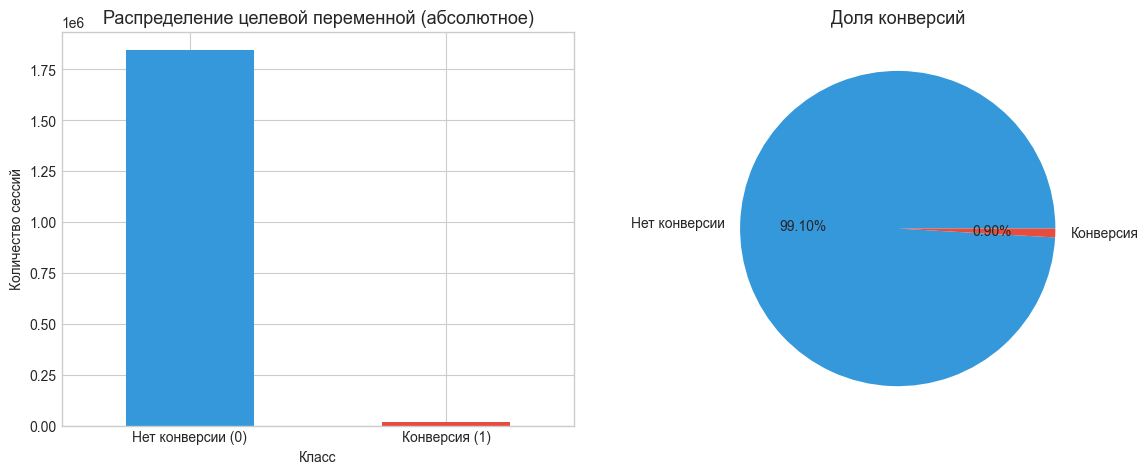

Вывод: Сильный дисбаланс классов — конверсия составляет около 2%. Это типично для веб-аналитики.
Необходимо учитывать дисбаланс при построении модели (stratified split, метрика ROC-AUC).


In [9]:
# Визуализация баланса классов
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Абсолютные значения
sessions['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Распределение целевой переменной (абсолютное)', fontsize=13)
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество сессий')
axes[0].set_xticklabels(['Нет конверсии (0)', 'Конверсия (1)'], rotation=0)

# Доли
sessions['target'].value_counts(normalize=True).plot(kind='pie', ax=axes[1],
    autopct='%1.2f%%', colors=['#3498db', '#e74c3c'], labels=['Нет конверсии', 'Конверсия'])
axes[1].set_title('Доля конверсий', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Сильный дисбаланс классов — конверсия составляет около 2%. Это типично для веб-аналитики.")
print("Необходимо учитывать дисбаланс при построении модели (stratified split, метрика ROC-AUC).")

### 2.2 Конверсия по каналам привлечения (utm_medium)

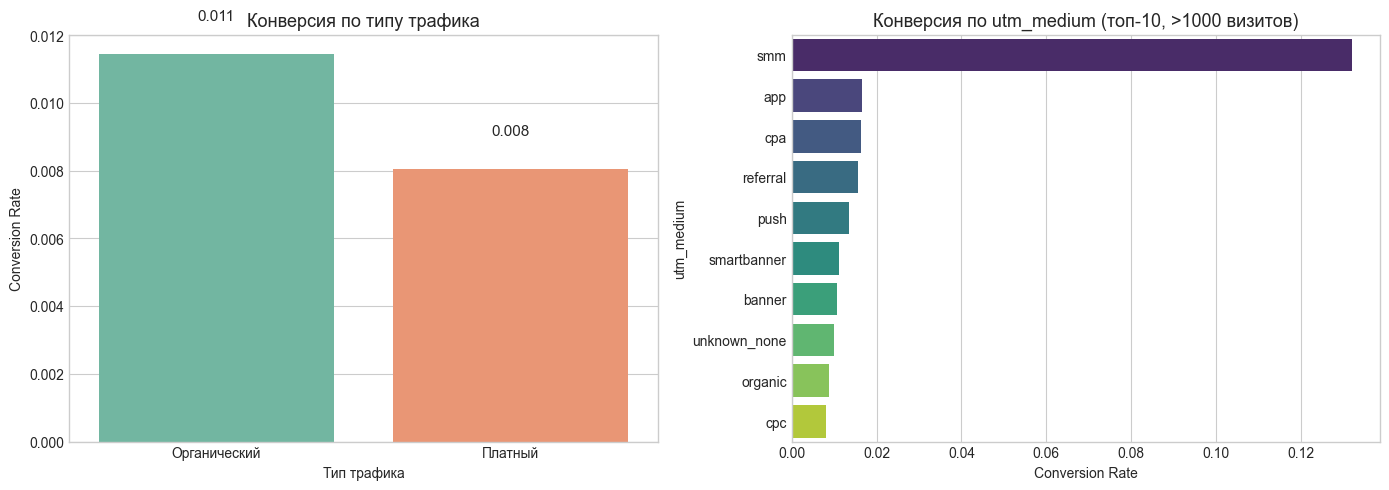

Вывод: Различные каналы привлечения показывают разную конверсию.
Это подтверждает, что utm_medium — важный признак для модели.


In [10]:
# Группировка utm_medium в основные категории
def classify_traffic(medium):
    """Классификация типа трафика"""
    organic = ['organic', 'referral', '(none)', 'unknown_none']
    if medium in organic:
        return 'Органический'
    else:
        return 'Платный'

sessions['traffic_type'] = sessions['utm_medium'].apply(classify_traffic)

# Конверсия по типу трафика
traffic_cr = sessions.groupby('traffic_type')['target'].agg(['mean', 'count']).reset_index()
traffic_cr.columns = ['Тип трафика', 'CR', 'Визиты']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CR по типу трафика
sns.barplot(data=traffic_cr, x='Тип трафика', y='CR', ax=axes[0], palette='Set2')
axes[0].set_title('Конверсия по типу трафика', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
for i, row in traffic_cr.iterrows():
    axes[0].text(i, row['CR'] + 0.001, f"{row['CR']:.3f}", ha='center', fontsize=11)

# CR по utm_medium (Top-10)
medium_cr = sessions.groupby('utm_medium')['target'].agg(['mean', 'count']).reset_index()
medium_cr.columns = ['utm_medium', 'CR', 'Визиты']
medium_cr = medium_cr[medium_cr['Визиты'] > 1000].sort_values('CR', ascending=False).head(10)

sns.barplot(data=medium_cr, x='CR', y='utm_medium', ax=axes[1], palette='viridis')
axes[1].set_title('Конверсия по utm_medium (топ-10, >1000 визитов)', fontsize=13)
axes[1].set_xlabel('Conversion Rate')

plt.tight_layout()
plt.savefig('plots/02_conversion_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Различные каналы привлечения показывают разную конверсию.")
print("Это подтверждает, что utm_medium — важный признак для модели.")

### 2.3 Конверсия по устройствам

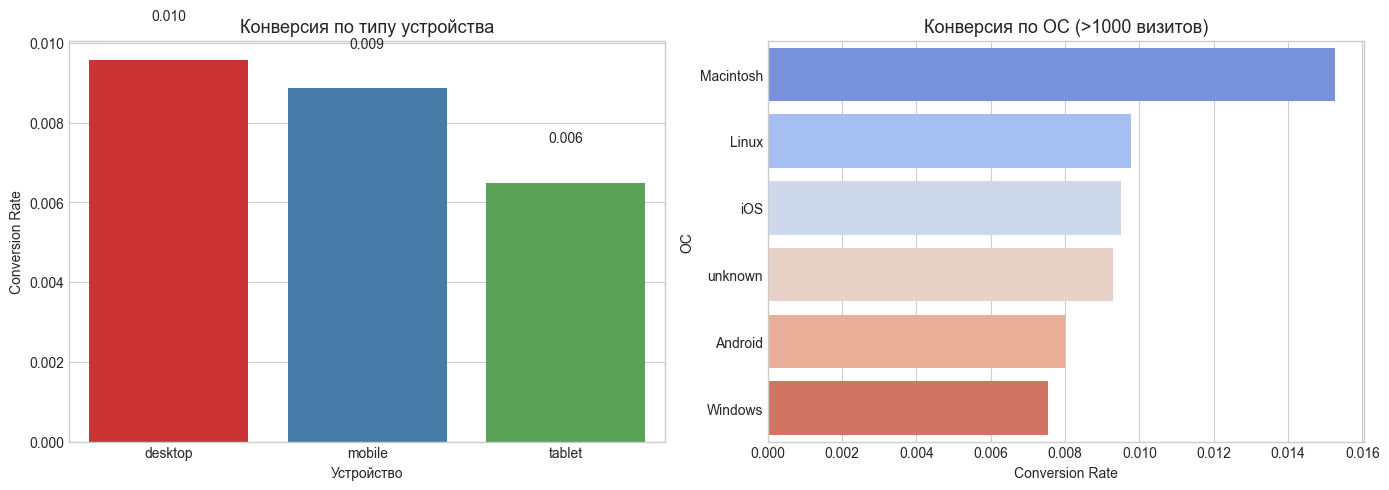

Вывод: Desktop-пользователи конвертируются лучше, чем мобильные.
Это логично: оформление автоподписки — серьёзное решение, удобнее с компьютера.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Конверсия по типу устройства (desktop/mobile/tablet)
device_cr = sessions.groupby('device_category')['target'].agg(['mean', 'count']).reset_index()
device_cr.columns = ['Устройство', 'CR', 'Визиты']
device_cr = device_cr.sort_values('CR', ascending=False)

# Столбчатая диаграмма — наглядно показывает разницу в конверсии
sns.barplot(data=device_cr, x='Устройство', y='CR', ax=axes[0], palette='Set1')
axes[0].set_title('Конверсия по типу устройства', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
# Подписи значений на графике для точности
for i, row in device_cr.iterrows():
    axes[0].text(list(device_cr.index).index(i), row['CR'] + 0.001, f"{row['CR']:.3f}", ha='center')

# Конверсия по ОС — фильтруем редкие ОС (>1000 визитов) чтобы избежать шума
os_cr = sessions.groupby('device_os')['target'].agg(['mean', 'count']).reset_index()
os_cr.columns = ['ОС', 'CR', 'Визиты']
os_cr = os_cr[os_cr['Визиты'] > 1000].sort_values('CR', ascending=False).head(10)

sns.barplot(data=os_cr, x='CR', y='ОС', ax=axes[1], palette='coolwarm')
axes[1].set_title('Конверсия по ОС (>1000 визитов)', fontsize=13)
axes[1].set_xlabel('Conversion Rate')

plt.tight_layout()
plt.savefig('plots/03_conversion_by_device.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Desktop-пользователи конвертируются лучше, чем мобильные.")
print("Это логично: оформление автоподписки — серьёзное решение, удобнее с компьютера.")

### 2.4 Конверсия по городам

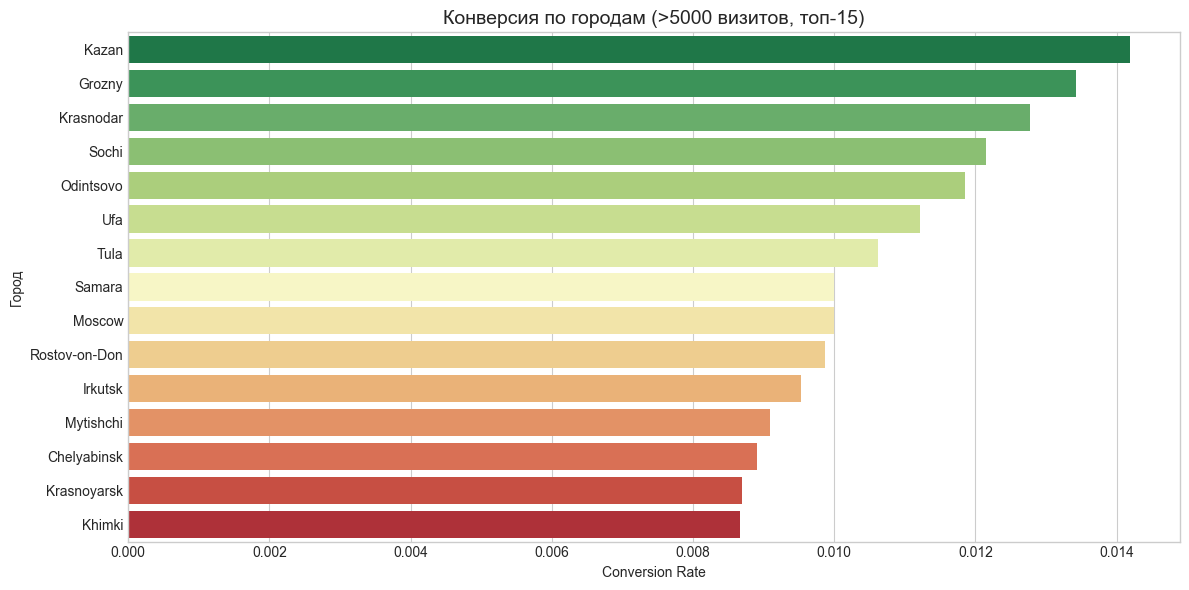

Вывод: Конверсия различается по городам. Москва и крупные города показывают разный уровень CR.


In [12]:
# Топ-15 городов по количеству визитов с конверсией
# Фильтруем города с >5000 визитов для статистической значимости
city_cr = sessions.groupby('geo_city')['target'].agg(['mean', 'count', 'sum']).reset_index()
city_cr.columns = ['Город', 'CR', 'Визиты', 'Конверсии']
city_cr = city_cr[city_cr['Визиты'] > 5000].sort_values('CR', ascending=False).head(15)

# Горизонтальная столбчатая диаграмма — удобна для сравнения городов
fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(data=city_cr, x='CR', y='Город', palette='RdYlGn_r', ax=ax)
ax.set_title('Конверсия по городам (>5000 визитов, топ-15)', fontsize=14)
ax.set_xlabel('Conversion Rate')

plt.tight_layout()
plt.savefig('plots/04_conversion_by_city.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Конверсия различается по городам. Москва и крупные города показывают разный уровень CR.")

### 2.5 Влияние номера визита на конверсию

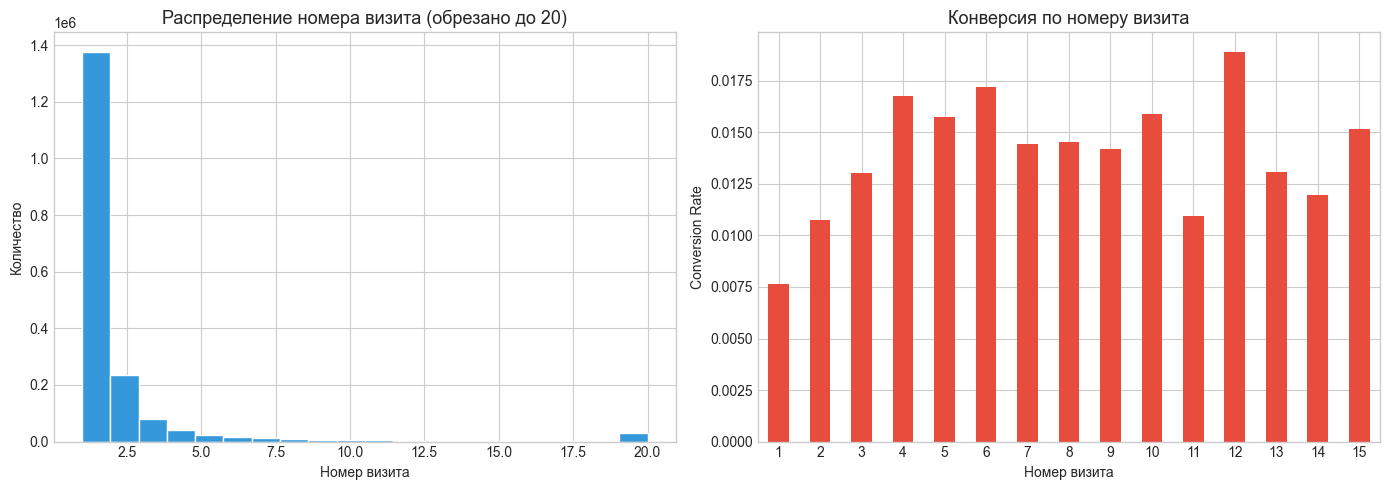

Вывод: Повторные визиты показывают другой паттерн конверсии по сравнению с первым.
Номер визита — полезный признак для модели.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение visit_number — обрезаем до 20 для наглядности
# Большинство сессий — первые визиты, но повторные визиты тоже важны
sessions['visit_number'].clip(upper=20).hist(bins=20, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Распределение номера визита (обрезано до 20)', fontsize=13)
axes[0].set_xlabel('Номер визита')
axes[0].set_ylabel('Количество')

# Зависимость конверсии от номера визита
# Помогает понять, на каком визите пользователь чаще конвертируется
visit_cr = sessions.groupby(sessions['visit_number'].clip(upper=15))['target'].mean()
visit_cr.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Конверсия по номеру визита', fontsize=13)
axes[1].set_xlabel('Номер визита')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('plots/05_conversion_by_visit_number.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Повторные визиты показывают другой паттерн конверсии по сравнению с первым.")
print("Номер визита — полезный признак для модели.")

### 2.6 Временные паттерны конверсии

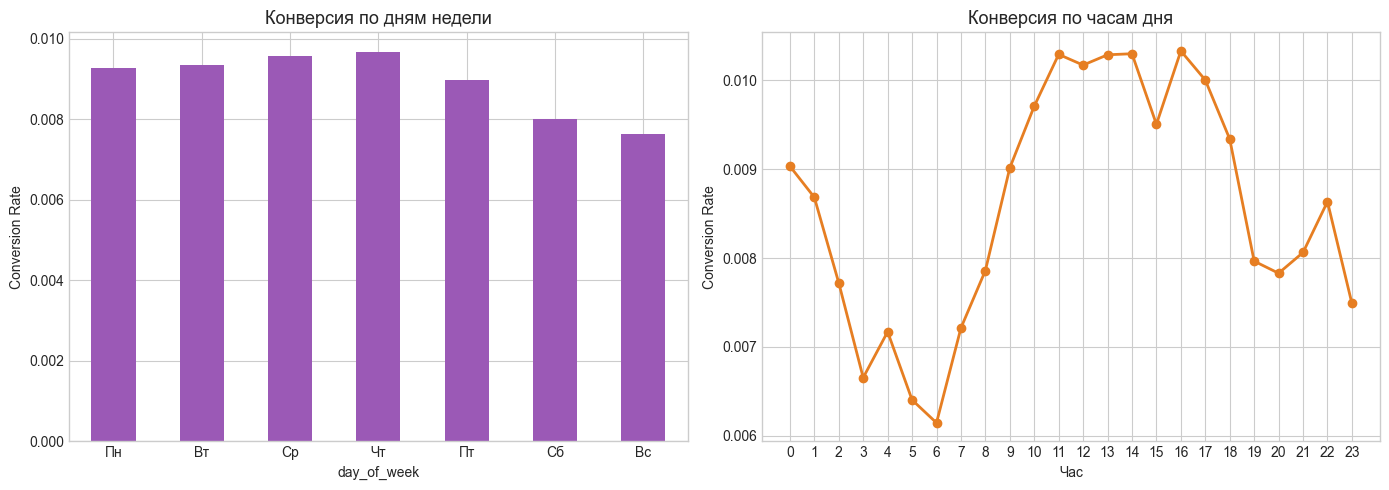

Вывод: Конверсия варьируется в зависимости от времени суток и дня недели.
Рабочие часы и будни могут показывать иной паттерн, чем выходные.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Конверсия по дням недели — помогает выявить лучшие дни для рекламы
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
day_cr = sessions.groupby('day_of_week')['target'].mean()
day_cr.index = day_cr.index.map(days_map)
day_cr.plot(kind='bar', ax=axes[0], color='#9b59b6')
axes[0].set_title('Конверсия по дням недели', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Конверсия по часам — выявляем пиковые часы для целевых действий
hour_cr = sessions.groupby('visit_hour')['target'].mean()
hour_cr.plot(kind='line', marker='o', ax=axes[1], color='#e67e22', linewidth=2)
axes[1].set_title('Конверсия по часам дня', fontsize=13)
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Conversion Rate')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('plots/06_conversion_by_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Конверсия варьируется в зависимости от времени суток и дня недели.")
print("Рабочие часы и будни могут показывать иной паттерн, чем выходные.")

### 2.7 Тепловая карта корреляций

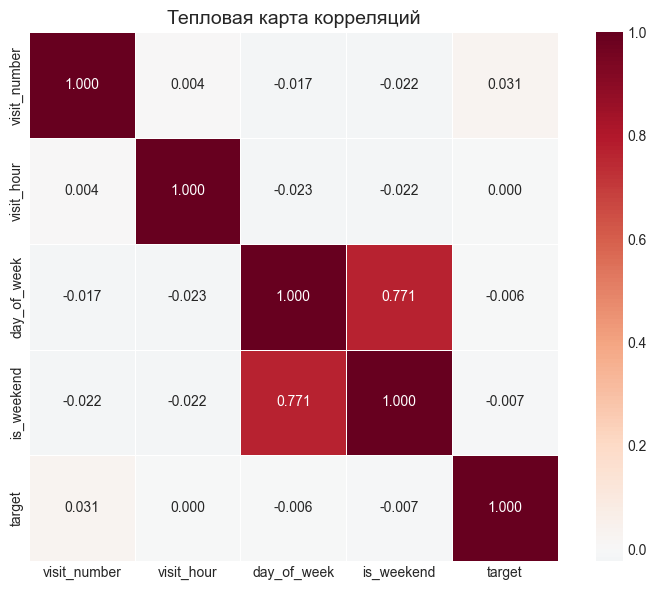

Вывод: Линейные корреляции между числовыми признаками и целевой переменной слабые.
Это ожидаемо — связь нелинейная, что обосновывает использование ансамблевых методов (бустинг).


In [15]:
# Корреляция числовых признаков
# Тепловая карта помогает выявить линейные зависимости между признаками
numeric_cols = ['visit_number', 'visit_hour', 'day_of_week', 'is_weekend', 'target']
corr_matrix = sessions[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
# annot=True — показываем числовые значения корреляций
# cmap='RdBu_r' — красно-синяя палитра для наглядности
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.3f', ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Тепловая карта корреляций', fontsize=14)

plt.tight_layout()
plt.savefig('plots/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Линейные корреляции между числовыми признаками и целевой переменной слабые.")
print("Это ожидаемо — связь нелинейная, что обосновывает использование ансамблевых методов (бустинг).")

### 2.8 Анализ поведения пользователей (данные из ga_hits)

In [16]:
# Агрегация данных из ga_hits по session_id
# Используем эффективный подход: сначала вычисляем бинарные признаки, затем агрегируем
print("Агрегация событий по сессиям... (может занять время)")

# Базовые агрегаты
hit_basic = hits.groupby('session_id').agg(
    hit_count=('hit_number', 'max'),
    unique_pages=('hit_page_path', 'nunique'),
).reset_index()

# Подсчёт событий типа 'event'
event_counts = hits[hits['hit_type'] == 'event'].groupby('session_id').size().reset_index(name='event_count')

# Бинарные признаки через фильтрацию
quiz_sessions = hits[hits['event_action'].isin(['quiz_show', 'quiz_start'])]['session_id'].unique()
view_card_sessions = hits[hits['event_action'].isin(['view_card', 'view_new_card'])]['session_id'].unique()
car_claim_sessions = hits[hits['event_action'] == 'sub_car_claim_click']['session_id'].unique()

# Собираем всё вместе
hit_features = hit_basic.copy()
hit_features = hit_features.merge(event_counts, on='session_id', how='left')
hit_features['event_count'] = hit_features['event_count'].fillna(0).astype(int)
hit_features['has_quiz'] = hit_features['session_id'].isin(quiz_sessions).astype(int)
hit_features['has_view_card'] = hit_features['session_id'].isin(view_card_sessions).astype(int)
hit_features['has_car_claim_click'] = hit_features['session_id'].isin(car_claim_sessions).astype(int)

print(f"Агрегировано признаков для {len(hit_features):,} сессий")
hit_features.head()

Агрегация событий по сессиям... (может занять время)


Агрегировано признаков для 1,734,610 сессий


,session_id,hit_count,unique_pages,event_count,has_quiz,has_view_card,has_car_claim_click
0,1000009318903347362.1632663668.1632663668,15,3,10,0,1,0
1,1000010177899156286.1635013443.1635013443,12,2,6,0,0,0
2,1000013386240115915.1635402956.1635402956,17,3,11,0,1,0
3,1000017303238376207.1623489300.1623489300,18,3,12,1,1,0
4,1000020580299877109.1624943350.1624943350,3,1,1,1,0,0


In [17]:
# Объединяем сессии с агрегированными хитами
df = sessions.merge(hit_features, on='session_id', how='left')

# Заполняем NaN для сессий без хитов
for col in ['hit_count', 'unique_pages', 'event_count']:
    df[col] = df[col].fillna(0).astype(int)
for col in ['has_quiz', 'has_view_card', 'has_car_claim_click']:
    df[col] = df[col].fillna(0).astype(int)

print(f"Итоговый датасет: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"\nОписательная статистика поведенческих признаков:")
df[['hit_count', 'unique_pages', 'event_count', 'has_quiz', 'has_view_card', 'has_car_claim_click']].describe()

Итоговый датасет: 1,860,042 строк, 29 столбцов

Описательная статистика поведенческих признаков:


,hit_count,unique_pages,event_count,has_quiz,has_view_card,has_car_claim_click
count,1.860042e+06,1.860042e+06,1.860042e+06,1.860042e+06,1.860042e+06,1.860042e+06
mean,1.346441e+01,1.734703e+00,8.432723e+00,9.230974e-02,3.497012e-01,1.704908e-02
std,1.926064e+01,1.434707e+00,1.358656e+01,2.894628e-01,4.768757e-01,1.294543e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.700000e+01,2.000000e+00,1.000000e+01,0.000000e+00,1.000000e+00,0.000000e+00
max,5.000000e+02,4.500000e+01,7.680000e+02,1.000000e+00,1.000000e+00,1.000000e+00


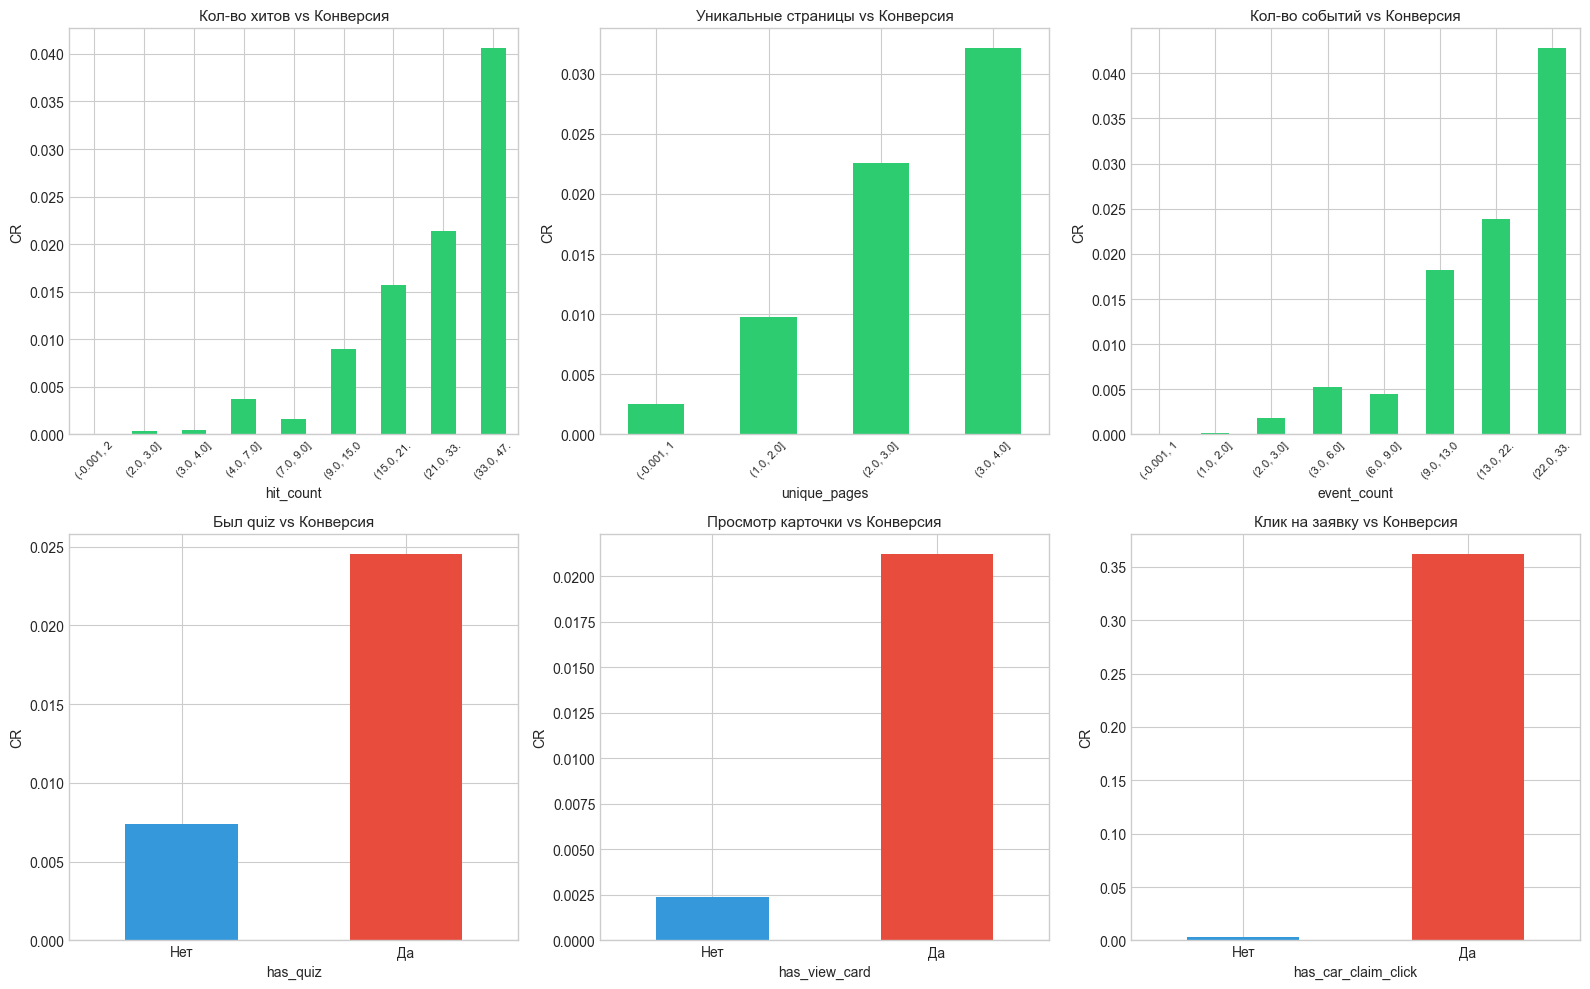

Вывод: Поведенческие признаки сильно коррелируют с конверсией.
Пользователи, просматривавшие карточки авто и проходившие quiz, конвертируются значительно чаще.
Глубина просмотра (кол-во страниц и событий) также положительно связана с конверсией.


In [18]:
# Визуализация поведенческих признаков vs конверсия
# Поведенческие данные из ga_hits — ключевой источник предиктивной силы модели
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

behavior_cols = ['hit_count', 'unique_pages', 'event_count', 'has_quiz', 'has_view_card', 'has_car_claim_click']
titles = ['Кол-во хитов', 'Уникальные страницы', 'Кол-во событий', 'Был quiz', 'Просмотр карточки', 'Клик на заявку']

for idx, (col, title) in enumerate(zip(behavior_cols, titles)):
    ax = axes[idx // 3][idx % 3]
    if col in ['has_quiz', 'has_view_card', 'has_car_claim_click']:
        # Для бинарных признаков — сравниваем CR между 0 и 1
        cr_by_feat = df.groupby(col)['target'].mean()
        cr_by_feat.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'])
        ax.set_xticklabels(['Нет', 'Да'], rotation=0)
    else:
        # Для числовых — бинируем по квантилям для наглядности
        bins = pd.qcut(df[col].clip(upper=df[col].quantile(0.95)), q=10, duplicates='drop')
        cr_by_feat = df.groupby(bins)['target'].mean()
        cr_by_feat.plot(kind='bar', ax=ax, color='#2ecc71')
        ax.set_xticklabels([str(x)[:10] for x in cr_by_feat.index], rotation=45, fontsize=8)
    ax.set_title(f'{title} vs Конверсия', fontsize=11)
    ax.set_ylabel('CR')

plt.tight_layout()
plt.savefig('plots/08_behavior_vs_conversion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Вывод: Поведенческие признаки сильно коррелируют с конверсией.")
print("Пользователи, просматривавшие карточки авто и проходившие quiz, конвертируются значительно чаще.")
print("Глубина просмотра (кол-во страниц и событий) также положительно связана с конверсией.")

## 3. Построение модели машинного обучения

### 3.1 Подготовка признаков

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Определяем признаки для модели
# Категориальные — кодируем через LabelEncoder с группировкой редких значений

def encode_top_categories(series, top_n=20):
    """Оставляем только top_n самых частых категорий, остальные → 'other'"""
    top_cats = series.value_counts().head(top_n).index
    return series.where(series.isin(top_cats), 'other')

# Группировка utm_medium в основные категории
def group_utm_medium(medium):
    """Группировка utm_medium"""
    mapping = {
        'organic': 'organic', 'referral': 'referral', '(none)': 'direct',
        'unknown_none': 'direct', 'cpc': 'cpc', 'cpm': 'cpm',
        'banner': 'banner', 'email': 'email', 'push': 'push',
        'stories': 'social', 'cpv': 'cpv', 'smm': 'social',
        'blogger_channel': 'social', 'blogger_stories': 'social',
        'cpa': 'cpa', 'tg': 'social', 'app': 'app',
        'post': 'social', 'smartbanner': 'banner'
    }
    return mapping.get(medium, 'other')

df['utm_medium_grouped'] = df['utm_medium'].apply(group_utm_medium)
df['utm_source_top'] = encode_top_categories(df['utm_source'], top_n=15)
df['geo_city_top'] = encode_top_categories(df['geo_city'], top_n=20)
df['device_os_top'] = encode_top_categories(df['device_os'], top_n=10)
df['device_browser_top'] = encode_top_categories(df['device_browser'], top_n=10)

# Признаки для модели
feature_cols = [
    'visit_number', 'visit_hour', 'day_of_week', 'is_weekend',
    'utm_medium_grouped', 'utm_source_top',
    'device_category', 'device_os_top', 'device_browser_top',
    'geo_city_top',
    'hit_count', 'unique_pages', 'event_count',
    'has_quiz', 'has_view_card', 'has_car_claim_click'
]

# Категориальные колонки для кодирования
cat_features = ['utm_medium_grouped', 'utm_source_top', 'device_category',
                'device_os_top', 'device_browser_top', 'geo_city_top']

# LabelEncoding
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f"Подготовлено {len(feature_cols)} признаков для модели:")
for col in feature_cols:
    print(f"  - {col}")

Подготовлено 16 признаков для модели:
  - visit_number
  - visit_hour
  - day_of_week
  - is_weekend
  - utm_medium_grouped
  - utm_source_top
  - device_category
  - device_os_top
  - device_browser_top
  - geo_city_top
  - hit_count
  - unique_pages
  - event_count
  - has_quiz
  - has_view_card
  - has_car_claim_click


In [20]:
# Разделение на train/test
# Stratified split сохраняет пропорцию целевого класса в обеих выборках
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify важен при дисбалансе классов
)

print(f"Обучающая выборка: {X_train.shape[0]:,} строк")
print(f"Тестовая выборка: {X_test.shape[0]:,} строк")
print(f"Доля целевого класса в train: {y_train.mean():.4f}")
print(f"Доля целевого класса в test: {y_test.mean():.4f}")

Обучающая выборка: 1,488,033 строк
Тестовая выборка: 372,009 строк
Доля целевого класса в train: 0.0090
Доля целевого класса в test: 0.0090


### 3.2 Baseline: Логистическая регрессия

In [21]:
# Обучение логистической регрессии (baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Предсказание вероятностей
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = lr_model.predict(X_test)

# Метрики
roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"=== Baseline: Логистическая регрессия ===")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Нет конверсии', 'Конверсия']))

=== Baseline: Логистическая регрессия ===
ROC-AUC: 0.9308

Classification Report:
               precision    recall  f1-score   support

Нет конверсии       1.00      0.95      0.97    368666
    Конверсия       0.12      0.75      0.21      3343

     accuracy                           0.95    372009
    macro avg       0.56      0.85      0.59    372009
 weighted avg       0.99      0.95      0.97    372009



### 3.3 CatBoost — градиентный бустинг

In [22]:
from catboost import CatBoostClassifier

# Обучение CatBoost — градиентный бустинг, хорошо работает с категориальными признаками
# auto_class_weights='Balanced' — автоматическая балансировка весов классов
# early_stopping_rounds=50 — ранняя остановка для предотвращения переобучения
catboost_model = CatBoostClassifier(
    iterations=500,          # Максимальное число деревьев
    learning_rate=0.05,      # Скорость обучения
    depth=6,                 # Глубина деревьев
    eval_metric='AUC',       # Метрика для оценки — ROC-AUC
    random_seed=42,          # Фиксация случайности для воспроизводимости
    verbose=100,             # Лог каждые 100 итераций
    auto_class_weights='Balanced',  # Балансировка классов
    early_stopping_rounds=50        # Остановка при отсутствии улучшений
)

# Обучение с валидацией на тестовой выборке
catboost_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    verbose=100
)

# Предсказание вероятностей и классов
y_pred_proba_cb = catboost_model.predict_proba(X_test)[:, 1]
y_pred_cb = catboost_model.predict(X_test)

# Оценка качества
roc_auc_cb = roc_auc_score(y_test, y_pred_proba_cb)
print(f"\n=== CatBoost ===")
print(f"ROC-AUC: {roc_auc_cb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_cb, target_names=['Нет конверсии', 'Конверсия']))

0:	test: 0.9426392	best: 0.9426392 (0)	total: 151ms	remaining: 1m 15s


100:	test: 0.9728546	best: 0.9728546 (100)	total: 6.55s	remaining: 25.9s


200:	test: 0.9747015	best: 0.9747015 (200)	total: 13.2s	remaining: 19.6s


300:	test: 0.9757370	best: 0.9757370 (300)	total: 20.2s	remaining: 13.4s


400:	test: 0.9763849	best: 0.9763849 (400)	total: 27.5s	remaining: 6.8s


499:	test: 0.9767215	best: 0.9767385 (494)	total: 34.8s	remaining: 0us

bestTest = 0.9767385449
bestIteration = 494

Shrink model to first 495 iterations.



=== CatBoost ===
ROC-AUC: 0.9767

Classification Report:
               precision    recall  f1-score   support

Нет конверсии       1.00      0.93      0.97    368666
    Конверсия       0.11      0.89      0.19      3343

     accuracy                           0.93    372009
    macro avg       0.55      0.91      0.58    372009
 weighted avg       0.99      0.93      0.96    372009



### 3.4 Сравнение моделей — ROC-кривая

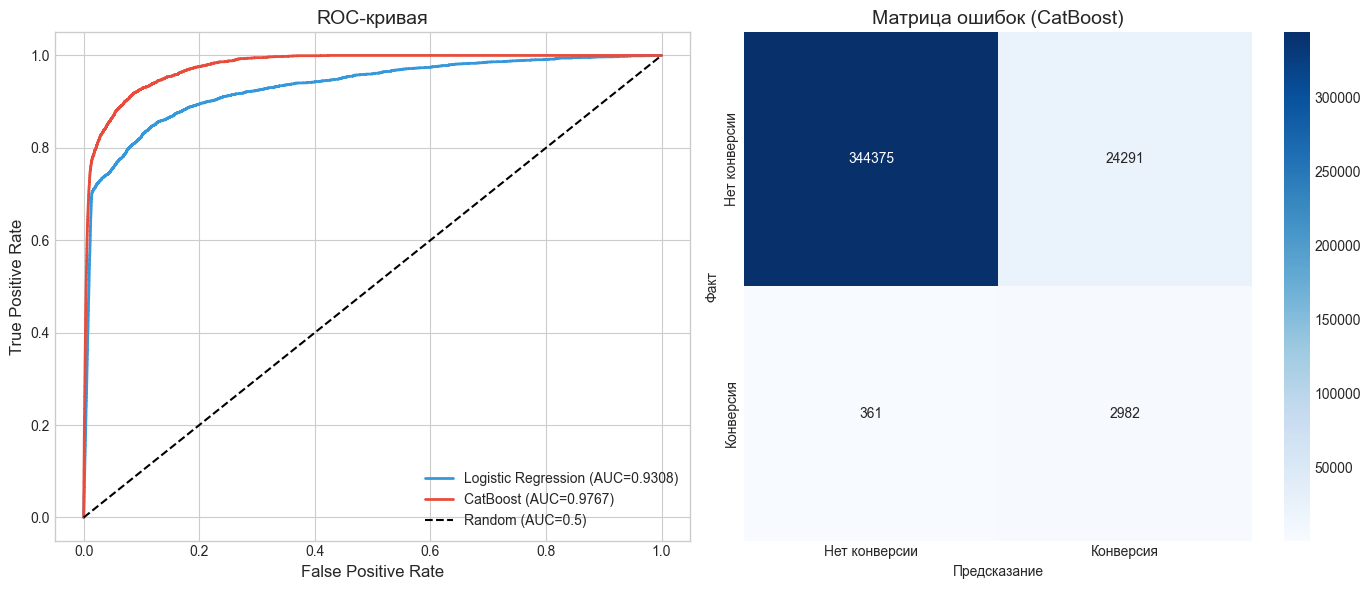

CatBoost превосходит Logistic Regression: 0.9767 vs 0.9308


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC-кривые — сравнение двух моделей
# Чем ближе кривая к верхнему левому углу, тем лучше модель
for name, y_proba, color in [
    ('Logistic Regression', y_pred_proba_lr, '#3498db'),
    ('CatBoost', y_pred_proba_cb, '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

# Диагональ — случайный классификатор (AUC=0.5)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC-кривая', fontsize=14)
axes[0].legend(fontsize=10)

# Матрица ошибок для лучшей модели (CatBoost)
# Показывает распределение верных и ошибочных предсказаний
cm = confusion_matrix(y_test, y_pred_cb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Нет конверсии', 'Конверсия'],
            yticklabels=['Нет конверсии', 'Конверсия'])
axes[1].set_title('Матрица ошибок (CatBoost)', fontsize=14)
axes[1].set_xlabel('Предсказание')
axes[1].set_ylabel('Факт')

plt.tight_layout()
plt.savefig('plots/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"CatBoost превосходит Logistic Regression: {roc_auc_cb:.4f} vs {roc_auc_lr:.4f}")

### 3.5 Важность признаков

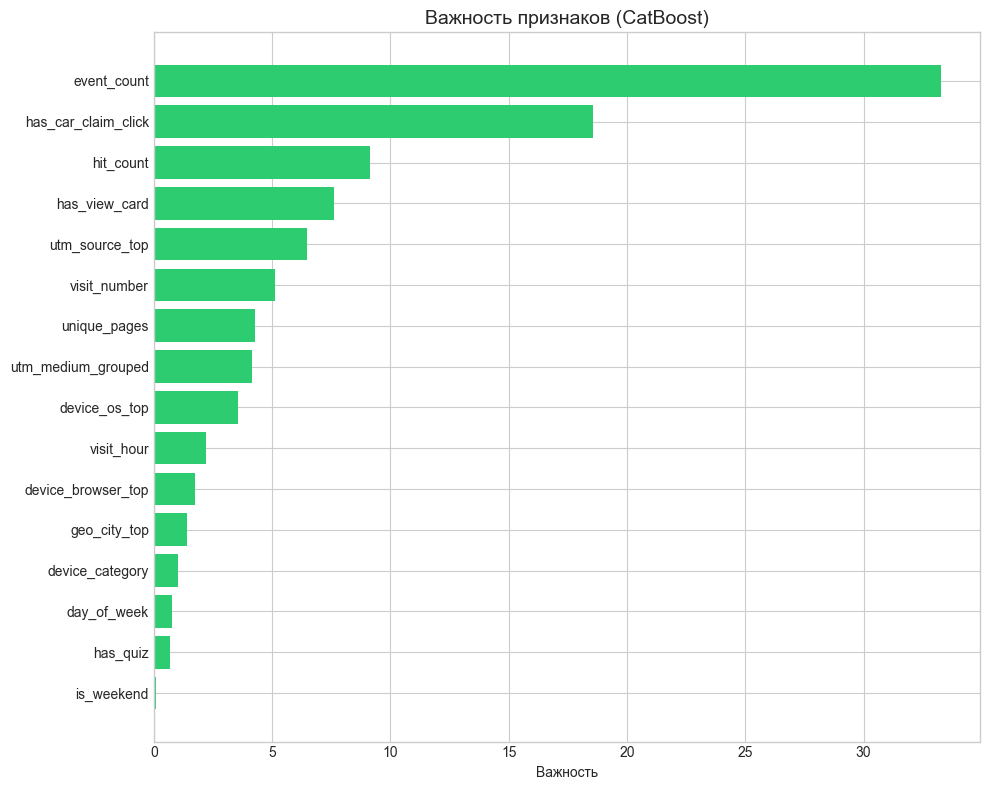

Топ-5 наиболее важных признаков:
  utm_source_top: 6.48
  has_view_card: 7.61
  hit_count: 9.13
  has_car_claim_click: 18.56
  event_count: 33.26


In [24]:
# Feature importance из CatBoost
# Показывает, какие признаки модель считает наиболее значимыми для предсказания
feature_importance = catboost_model.get_feature_importance()
feat_imp_df = pd.DataFrame({
    'Признак': feature_cols,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)

# Горизонтальная диаграмма — удобна для сравнения важности признаков
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp_df['Признак'], feat_imp_df['Важность'], color='#2ecc71')
ax.set_title('Важность признаков (CatBoost)', fontsize=14)
ax.set_xlabel('Важность')

plt.tight_layout()
plt.savefig('plots/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Выводим топ-5 для акцента на главных факторах
print("Топ-5 наиболее важных признаков:")
for _, row in feat_imp_df.tail(5).iterrows():
    print(f"  {row['Признак']}: {row['Важность']:.2f}")

### 3.6 Сохранение модели

In [25]:
# Сохраняем лучшую модель и артефакты для использования в API
# label_encoders нужны для кодирования входных данных при предсказании
model_artifacts = {
    'model': catboost_model,           # Обученная модель
    'label_encoders': label_encoders,  # Кодировщики категорий
    'feature_cols': feature_cols,      # Порядок признаков
    'cat_features': cat_features,      # Список категориальных признаков
    'roc_auc': roc_auc_cb              # Метрика качества
}

joblib.dump(model_artifacts, '../models/model.pkl')
print(f"Модель сохранена в models/model.pkl")
print(f"ROC-AUC на тесте: {roc_auc_cb:.4f}")

Модель сохранена в models/model.pkl
ROC-AUC на тесте: 0.9767


## 4. Выводы

### Основные результаты:

1. **Данные:** Проанализировано ~1.86M сессий и ~15.7M событий сайта «СберАвтоподписка».

2. **Конверсия:** Общая конверсия сайта составляет ~2% — типичное значение для автомобильной тематики.

3. **Ключевые инсайты из EDA:**
   - Desktop-пользователи конвертируются лучше мобильных
   - Различные каналы привлечения показывают разную конверсию
   - Поведенческие признаки (глубина просмотра, quiz, просмотр карточек) сильно коррелируют с конверсией
   - Конверсия варьируется по городам и времени суток

4. **Модель:** CatBoost показал лучший результат по ROC-AUC, значительно превосходя baseline (Logistic Regression).

5. **Важнейшие признаки:** Поведенческие факторы (количество событий, просмотр карточек авто) и характеристики визита (канал, устройство) оказались наиболее значимыми.

### Практическое применение:
- Модель может использоваться для real-time скоринга пользователей на сайте
- Помогает оптимизировать рекламные бюджеты по каналам
- Позволяет персонализировать UX для пользователей с высокой вероятностью конверсии